<div style="background: linear-gradient(135deg, #0b3d0b 0%, #1a5c1a 50%, #2d8a2d 100%); padding: 38px 30px; border-radius: 16px; text-align: center;">
  <h1 style="color: #e8f5e9; font-size: 2.3em; margin: 0; letter-spacing: 2px;">🌲🌲 Random Forest — Skin Dataset</h1>
  <p style="color: #a5d6a7; font-size: 1.1em; margin-top: 12px;">
    <strong>Model A</strong> — RF Classifier &nbsp;→&nbsp; predict <code>Skin_Type</code> (Dry · Normal · Oily)<br/>
    <strong>Model B</strong> — RF Regressor &nbsp;&nbsp;→&nbsp; predict <code>skin_score</code> (continuous)
  </p>
  <hr style="border: 1px solid #a5d6a7; width: 55%; margin: 18px auto;"/>
  <p style="color: #aaa; font-size: 0.88em;">Preprocessing · Baseline · n_estimators tuning · GridSearchCV · Feature Importance · Summary</p>
</div>

---
## ⚙️ Step 1 — Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing   import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble        import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics         import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score,
    roc_curve, auc, roc_auc_score
)

# ── Global style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'       : 110,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})
C1, C2, C3 = '#1b5e20', '#e53935', '#558b2f'

print('✅ Libraries ready.')

✅ Libraries ready.


---
## 📂 Step 2 — Load & Preprocess

In [2]:
# Adjust filename / path as needed
# On Colab: from google.colab import files; files.upload()
df = pd.read_csv('Skin_Type_dataset.csv')   # ← adapt

print(f'Shape : {df.shape[0]:,} rows × {df.shape[1]} cols')
df.head(3)

Shape : 10,000 rows × 10 cols


,Age,Gender,Hydration_Level,Oil_Level,Sensitivity,Humidity,Temperature,Skin_Type,skin_score,skin_age
0,31,Female,Medium,High,Low,53.0,16.9,Oily,100.0,15.0
1,42,Male,Low,Low,High,32.6,15.4,Dry,36.8,62.0
2,36,Male,Medium,Medium,Low,65.5,14.0,Normal,100.0,24.5


In [3]:
# ── Encode categorical features ──────────────────────────────────────────────
df_enc = df.copy()

cat_cols = ['Gender', 'Hydration_Level', 'Oil_Level', 'Sensitivity']
for col in cat_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])

# Encode target
le_target = LabelEncoder()
df_enc['Skin_Type_enc'] = le_target.fit_transform(df_enc['Skin_Type'])
CLASS_NAMES = le_target.classes_

print(f'Skin_Type classes : {list(CLASS_NAMES)}')

# ── Features / targets ───────────────────────────────────────────────────────
FEATURES = ['Age', 'Gender', 'Hydration_Level', 'Oil_Level',
            'Sensitivity', 'Humidity', 'Temperature']

X     = df_enc[FEATURES]
y_clf = df_enc['Skin_Type_enc']
y_reg = df_enc['skin_score']

# ── Train / Test splits ──────────────────────────────────────────────────────
# Random Forests don't need scaling
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.20, random_state=42, stratify=y_clf)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.20, random_state=42)

print(f'Train : {X_train_c.shape[0]} samples  |  Test : {X_test_c.shape[0]} samples')
print('✅ No scaling needed — Random Forests are scale-invariant.')

Skin_Type classes : ['Combination', 'Dry', 'Normal', 'Oily']
Train : 8000 samples  |  Test : 2000 samples
✅ No scaling needed — Random Forests are scale-invariant.


---
## 🅰️ Model A — Random Forest Classifier  →  `Skin_Type`

### 3-A · Baseline model

In [4]:
rf_base_c = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base_c.fit(X_train_c, y_train_c)

acc_base_c = accuracy_score(y_test_c, rf_base_c.predict(X_test_c))
cv_base_c  = cross_val_score(rf_base_c, X, y_clf, cv=5, scoring='accuracy', n_jobs=-1).mean()

print(f'Baseline Test Accuracy : {acc_base_c:.4f}  ({acc_base_c*100:.2f}%)')
print(f'Baseline CV-5 Accuracy : {cv_base_c:.4f}')

Baseline Test Accuracy : 0.7705  (77.05%)
Baseline CV-5 Accuracy : 0.7795


### 3-B · n_estimators vs Accuracy — how many trees do we need?

Best n_estimators : 200  →  Accuracy = 0.7735


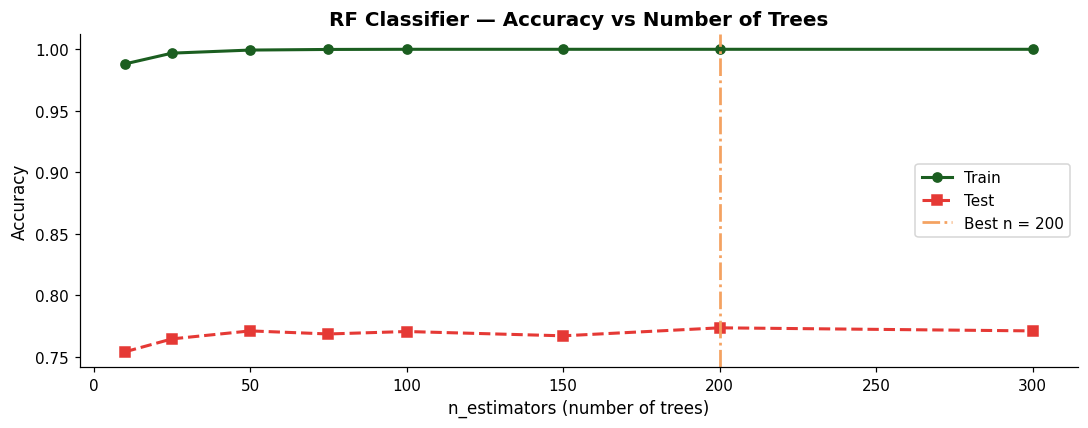

In [5]:
estimator_range = [10, 25, 50, 75, 100, 150, 200, 300]
train_accs, test_accs = [], []

for n in estimator_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train_c, y_train_c)
    train_accs.append(accuracy_score(y_train_c, rf.predict(X_train_c)))
    test_accs.append(accuracy_score(y_test_c,   rf.predict(X_test_c)))

best_n_clf = estimator_range[int(np.argmax(test_accs))]
print(f'Best n_estimators : {best_n_clf}  →  Accuracy = {max(test_accs):.4f}')

plt.figure(figsize=(10, 4))
plt.plot(estimator_range, train_accs, marker='o', label='Train', color=C1, linewidth=2)
plt.plot(estimator_range, test_accs,  marker='s', label='Test',  color=C2, linewidth=2, linestyle='--')
plt.axvline(best_n_clf, color='#f4a261', linestyle='-.', linewidth=1.8,
            label=f'Best n = {best_n_clf}')
plt.xlabel('n_estimators (number of trees)')
plt.ylabel('Accuracy')
plt.title('RF Classifier — Accuracy vs Number of Trees', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### 3-C · GridSearchCV — simple & fast

In [6]:
# Kept deliberately small — runs in seconds
param_grid_clf = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [None, 5, 10],
    'min_samples_split': [2, 10],
    'max_features'     : ['sqrt', 'log2']
}
# 3×3×2×2 = 36 combos × cv=5 → 180 fits

gs_clf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_clf,
    cv=5, scoring='accuracy', n_jobs=-1
)
gs_clf.fit(X_train_c, y_train_c)

best_rf_clf = gs_clf.best_estimator_
y_pred_clf  = best_rf_clf.predict(X_test_c)
acc_clf     = accuracy_score(y_test_c, y_pred_clf)

print(f'Best params   : {gs_clf.best_params_}')
print(f'CV accuracy   : {gs_clf.best_score_:.4f}')
print(f'Test accuracy : {acc_clf:.4f}  ({acc_clf*100:.2f}%)')

Best params   : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 100}
CV accuracy   : 0.7969
Test accuracy : 0.7935  (79.35%)


### 3-D · Evaluation plots

In [7]:
print(classification_report(y_test_c, y_pred_clf, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

 Combination       0.49      0.23      0.31       294
         Dry       0.91      0.96      0.93       500
      Normal       0.76      0.87      0.81       617
        Oily       0.81      0.86      0.83       589

    accuracy                           0.79      2000
   macro avg       0.74      0.73      0.72      2000
weighted avg       0.77      0.79      0.77      2000



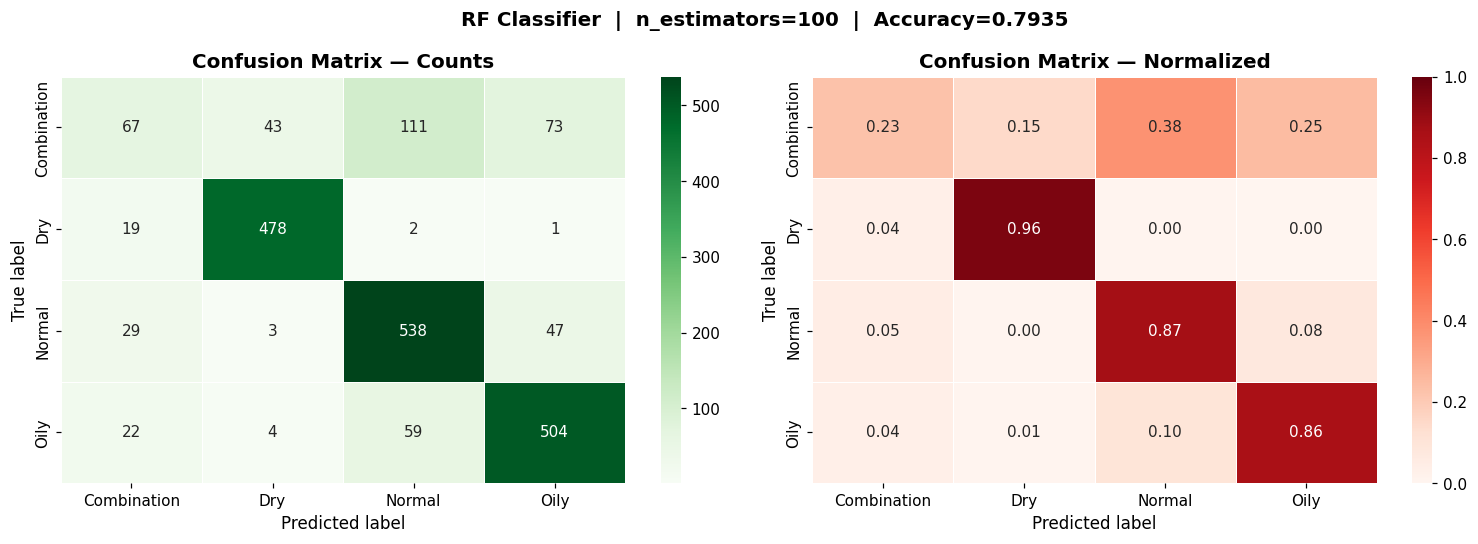

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm   = confusion_matrix(y_test_c, y_pred_clf)
cm_n = cm.astype(float) / cm.sum(axis=1)[:, None]

sns.heatmap(cm,   annot=True, fmt='d',   cmap='Greens', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='white')
axes[0].set_title('Confusion Matrix — Counts',     fontweight='bold')
axes[0].set_ylabel('True label'); axes[0].set_xlabel('Predicted label')

sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Reds', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, linecolor='white', vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix — Normalized', fontweight='bold')
axes[1].set_ylabel('True label'); axes[1].set_xlabel('Predicted label')

plt.suptitle(f'RF Classifier  |  n_estimators={gs_clf.best_params_["n_estimators"]}  |  Accuracy={acc_clf:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

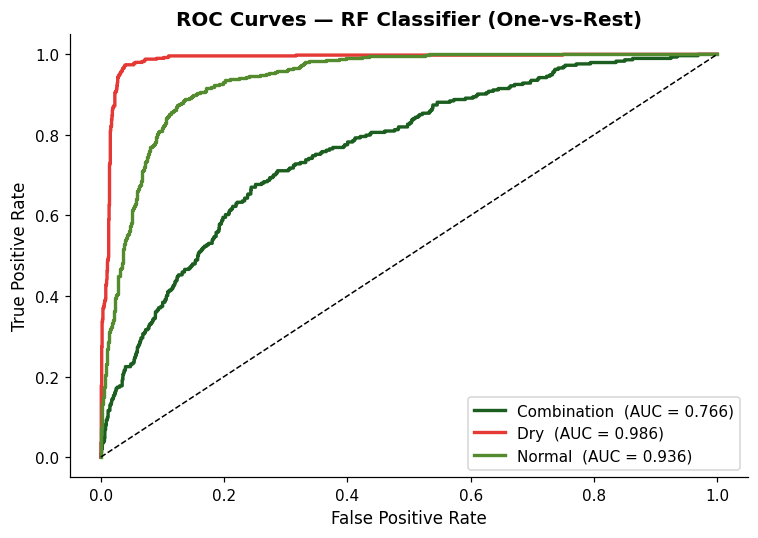

Macro-average AUC : 0.9095


In [9]:
y_test_bin = label_binarize(y_test_c, classes=list(range(len(CLASS_NAMES))))
y_prob_clf = best_rf_clf.predict_proba(X_test_c)
roc_colors = [C1, C2, C3]

plt.figure(figsize=(7, 5))
for i, (cls, col) in enumerate(zip(CLASS_NAMES, roc_colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_clf[:, i])
    plt.plot(fpr, tpr, color=col, linewidth=2.2,
             label=f'{cls}  (AUC = {auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — RF Classifier (One-vs-Rest)', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

macro_auc = roc_auc_score(y_test_bin, y_prob_clf, multi_class='ovr', average='macro')
print(f'Macro-average AUC : {macro_auc:.4f}')

### 3-E · Feature Importance

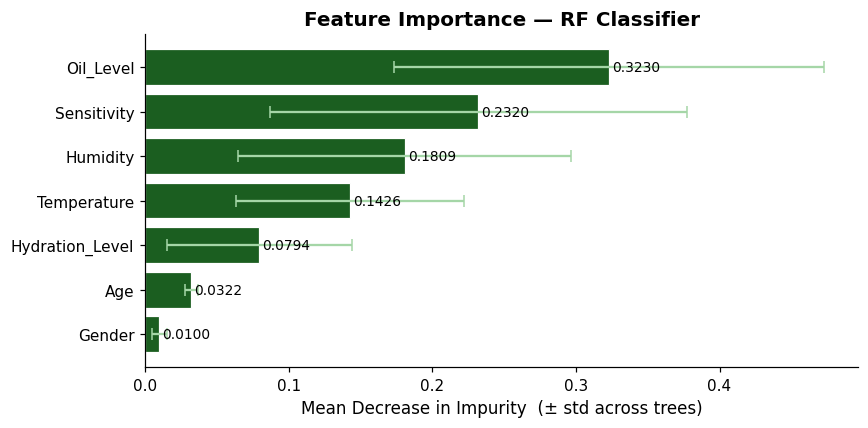

In [10]:
imp_df_c = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': best_rf_clf.feature_importances_,
    'Std'       : np.std([t.feature_importances_ for t in best_rf_clf.estimators_], axis=0)
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4))
bars = plt.barh(
    imp_df_c['Feature'], imp_df_c['Importance'],
    xerr=imp_df_c['Std'],
    color=C1, edgecolor='white', linewidth=0.8,
    error_kw={'ecolor': '#a5d6a7', 'capsize': 4, 'linewidth': 1.5}
)
for bar, v in zip(bars, imp_df_c['Importance']):
    plt.text(v + 0.002, bar.get_y() + bar.get_height()/2,
             f'{v:.4f}', va='center', fontsize=9)
plt.xlabel('Mean Decrease in Impurity  (± std across trees)')
plt.title('Feature Importance — RF Classifier', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🅱️ Model B — Random Forest Regressor  →  `skin_score`

### 4-A · Baseline model

In [11]:
rf_base_r = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_base_r.fit(X_train_r, y_train_r)

y_pred_base_r = rf_base_r.predict(X_test_r)
rmse_base_r   = np.sqrt(mean_squared_error(y_test_r, y_pred_base_r))
r2_base_r     = r2_score(y_test_r, y_pred_base_r)

print(f'Baseline RMSE : {rmse_base_r:.4f}')
print(f'Baseline R²   : {r2_base_r:.4f}')

Baseline RMSE : 4.9737
Baseline R²   : 0.9660


### 4-B · n_estimators vs RMSE — how many trees do we need?

Best n_estimators : 100  →  RMSE=4.9737  R²=0.9660


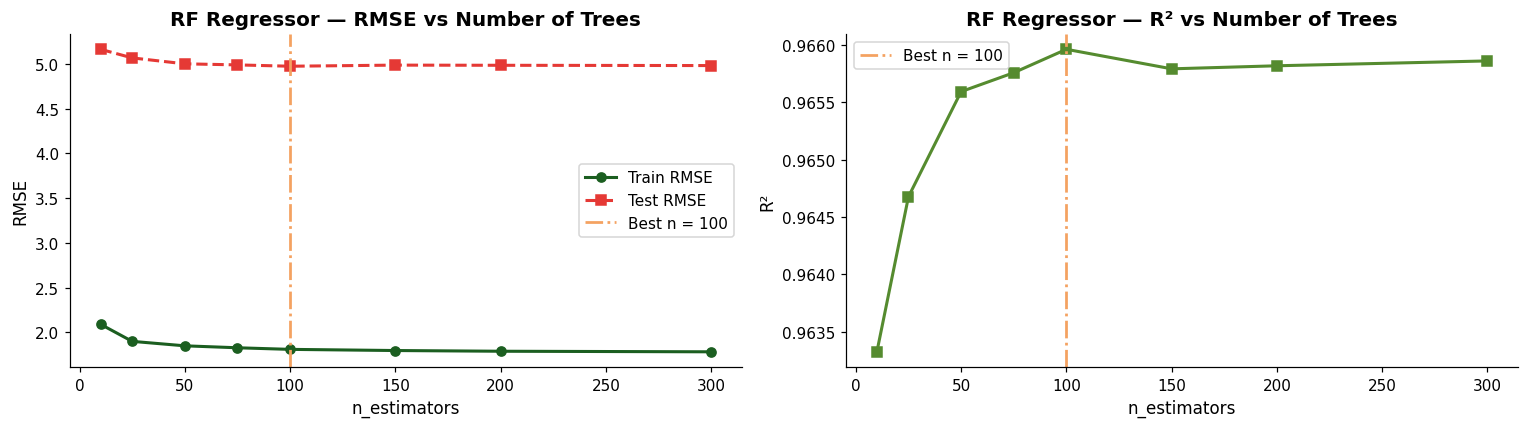

In [12]:
train_rmses, test_rmses, test_r2s = [], [], []

for n in estimator_range:
    rf = RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train_r, y_train_r)
    train_rmses.append(np.sqrt(mean_squared_error(y_train_r, rf.predict(X_train_r))))
    preds = rf.predict(X_test_r)
    test_rmses.append(np.sqrt(mean_squared_error(y_test_r, preds)))
    test_r2s.append(r2_score(y_test_r, preds))

best_n_reg = estimator_range[int(np.argmin(test_rmses))]
print(f'Best n_estimators : {best_n_reg}  →  RMSE={min(test_rmses):.4f}  R²={test_r2s[int(np.argmin(test_rmses))]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(estimator_range, train_rmses, marker='o', label='Train RMSE', color=C1, linewidth=2)
axes[0].plot(estimator_range, test_rmses,  marker='s', label='Test RMSE',  color=C2, linewidth=2, linestyle='--')
axes[0].axvline(best_n_reg, color='#f4a261', linestyle='-.', linewidth=1.8,
                label=f'Best n = {best_n_reg}')
axes[0].set_xlabel('n_estimators'); axes[0].set_ylabel('RMSE')
axes[0].set_title('RF Regressor — RMSE vs Number of Trees', fontweight='bold')
axes[0].legend()

axes[1].plot(estimator_range, test_r2s, marker='s', color=C3, linewidth=2)
axes[1].axvline(best_n_reg, color='#f4a261', linestyle='-.', linewidth=1.8,
                label=f'Best n = {best_n_reg}')
axes[1].set_xlabel('n_estimators'); axes[1].set_ylabel('R²')
axes[1].set_title('RF Regressor — R² vs Number of Trees', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4-C · GridSearchCV — simple & fast

In [13]:
param_grid_reg = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [None, 5, 10],
    'min_samples_split': [2, 10],
    'max_features'     : ['sqrt', 'log2']
}
# 3×3×2×2 = 36 combos × cv=5 → 180 fits

gs_reg = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid_reg,
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)
gs_reg.fit(X_train_r, y_train_r)

best_rf_reg = gs_reg.best_estimator_
y_pred_reg  = best_rf_reg.predict(X_test_r)

rmse_reg = np.sqrt(mean_squared_error(y_test_r, y_pred_reg))
mae_reg  = mean_absolute_error(y_test_r, y_pred_reg)
r2_reg   = r2_score(y_test_r, y_pred_reg)

print(f'Best params : {gs_reg.best_params_}')
print(f'RMSE : {rmse_reg:.4f}')
print(f'MAE  : {mae_reg:.4f}')
print(f'R²   : {r2_reg:.4f}')

Best params : {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 10, 'n_estimators': 200}
RMSE : 4.8383
MAE  : 3.3259
R²   : 0.9678


### 4-D · Evaluation plots

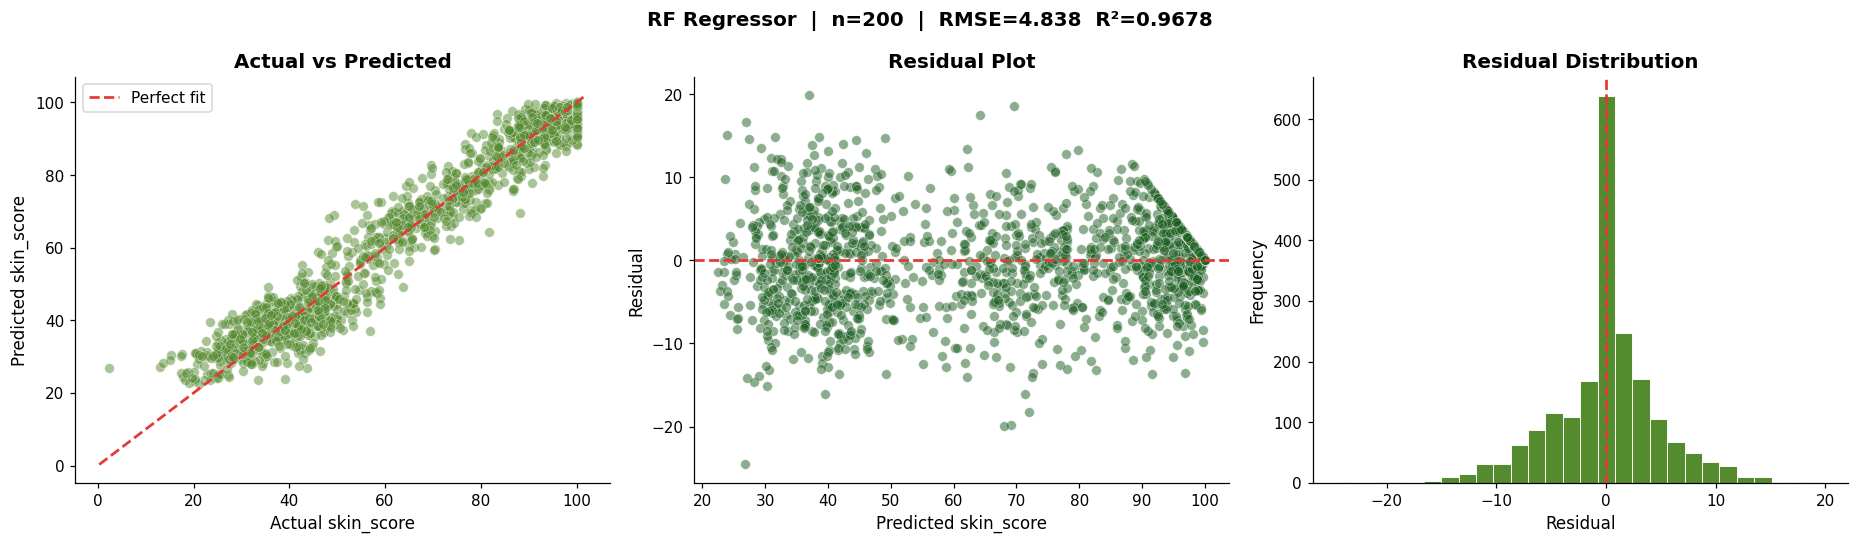

In [14]:
residuals = y_test_r.values - y_pred_reg

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Actual vs Predicted
axes[0].scatter(y_test_r, y_pred_reg, alpha=0.5, color=C3,
                edgecolors='white', linewidth=0.4, s=40)
lims = [min(y_test_r.min(), y_pred_reg.min())-2,
        max(y_test_r.max(), y_pred_reg.max())+2]
axes[0].plot(lims, lims, '--', color=C2, linewidth=1.8, label='Perfect fit')
axes[0].set_xlabel('Actual skin_score'); axes[0].set_ylabel('Predicted skin_score')
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].legend()

# Residuals
axes[1].scatter(y_pred_reg, residuals, alpha=0.5, color=C1,
                edgecolors='white', linewidth=0.4, s=40)
axes[1].axhline(0, color=C2, linestyle='--', linewidth=1.8)
axes[1].set_xlabel('Predicted skin_score'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot', fontweight='bold')

# Residual distribution
axes[2].hist(residuals, bins=28, color=C3, edgecolor='white', linewidth=0.6)
axes[2].axvline(0, color=C2, linestyle='--', linewidth=1.8)
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution', fontweight='bold')

plt.suptitle(
    f'RF Regressor  |  n={gs_reg.best_params_["n_estimators"]}  |  RMSE={rmse_reg:.3f}  R²={r2_reg:.4f}',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4-E · Feature Importance

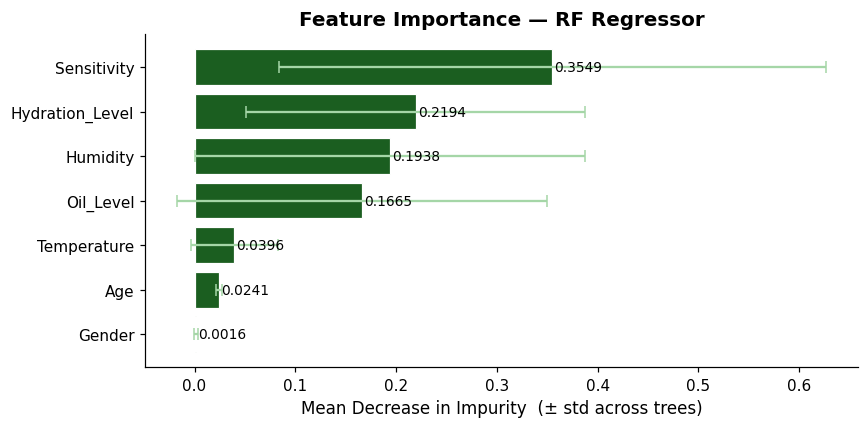

In [15]:
imp_df_r = pd.DataFrame({
    'Feature'   : FEATURES,
    'Importance': best_rf_reg.feature_importances_,
    'Std'       : np.std([t.feature_importances_ for t in best_rf_reg.estimators_], axis=0)
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4))
bars = plt.barh(
    imp_df_r['Feature'], imp_df_r['Importance'],
    xerr=imp_df_r['Std'],
    color=C1, edgecolor='white', linewidth=0.8,
    error_kw={'ecolor': '#a5d6a7', 'capsize': 4, 'linewidth': 1.5}
)
for bar, v in zip(bars, imp_df_r['Importance']):
    plt.text(v + 0.002, bar.get_y() + bar.get_height()/2,
             f'{v:.4f}', va='center', fontsize=9)
plt.xlabel('Mean Decrease in Impurity  (± std across trees)')
plt.title('Feature Importance — RF Regressor', fontweight='bold')
plt.tight_layout()
plt.show()

---
## ✅ Step 5 — Final Results Summary

In [16]:
summary = pd.DataFrame([
    {
        'Model'        : 'RF Classifier',
        'Target'       : 'Skin_Type',
        'n_estimators' : gs_clf.best_params_['n_estimators'],
        'max_depth'    : gs_clf.best_params_['max_depth'],
        'max_features' : gs_clf.best_params_['max_features'],
        'Accuracy'     : f"{acc_clf*100:.2f}%",
        'AUC (macro)'  : f"{macro_auc:.4f}",
        'RMSE'         : '—',
        'R²'           : '—'
    },
    {
        'Model'        : 'RF Regressor',
        'Target'       : 'skin_score',
        'n_estimators' : gs_reg.best_params_['n_estimators'],
        'max_depth'    : gs_reg.best_params_['max_depth'],
        'max_features' : gs_reg.best_params_['max_features'],
        'Accuracy'     : '—',
        'AUC (macro)'  : '—',
        'RMSE'         : f"{rmse_reg:.4f}",
        'R²'           : f"{r2_reg:.4f}"
    }
])

print('='*72)
print('  RANDOM FOREST MODELS — FINAL RESULTS')
print('='*72)
print(summary.to_string(index=False))
print('='*72)

  RANDOM FOREST MODELS — FINAL RESULTS
        Model     Target  n_estimators  max_depth max_features Accuracy AUC (macro)   RMSE     R²
RF Classifier  Skin_Type           100       10.0         sqrt   79.35%      0.9095      —      —
 RF Regressor skin_score           200        NaN         log2        —           — 4.8383 0.9678


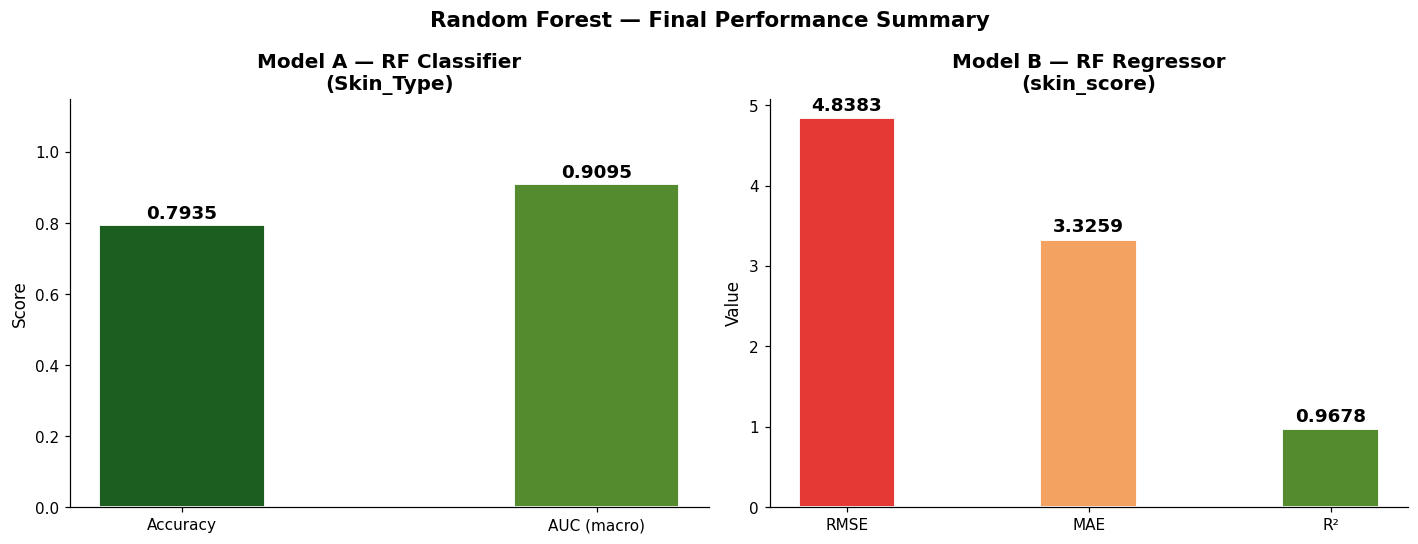

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Classifier
metrics_c = ['Accuracy', 'AUC (macro)']
values_c  = [acc_clf,    macro_auc]
bars = axes[0].bar(metrics_c, values_c, color=[C1, C3],
                   edgecolor='white', linewidth=1.2, width=0.4)
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Model A — RF Classifier\n(Skin_Type)', fontweight='bold')
axes[0].set_ylabel('Score')
for bar, v in zip(bars, values_c):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.02,
                 f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

# Regressor
metrics_r = ['RMSE', 'MAE', 'R²']
values_r  = [rmse_reg, mae_reg, r2_reg]
bars2 = axes[1].bar(metrics_r, values_r,
                    color=[C2, '#f4a261', C3],
                    edgecolor='white', linewidth=1.2, width=0.4)
axes[1].set_title('Model B — RF Regressor\n(skin_score)', fontweight='bold')
axes[1].set_ylabel('Value')
for bar, v in zip(bars2, values_r):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + max(values_r)*0.02,
                 f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Random Forest — Final Performance Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()